# Experimento C: Detección de cuellos de botella

**Objetivo:** Simular un pipeline de ingesta, transfor
macion y almacenamiento, medir tiempos por etapa y determinar el cuello de botella principal.

###  1. Importación de librerías

In [23]:
import time
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

### 2. Configuración

In [24]:
datos_dir = Path("../datos")
datos_dir.mkdir(exist_ok=True)
# Configuraciones del experimento
configs = [
    {"n_rows": 100_000, "transform": "simple"},
    {"n_rows": 100_000, "transform": "compleja"},
    {"n_rows": 500_000, "transform": "simple"},
    {"n_rows": 500_000, "transform": "compleja"},
    {"n_rows": 1_000_000, "transform": "simple"},
    {"n_rows": 1_000_000, "transform": "compleja"},
    {"n_rows": 5_000_000, "transform": "simple"},
    {"n_rows": 5_000_000, "transform": "compleja"}
]
repetitions = 3

### 3. Funciones del pipeline

In [25]:
def ingesta(n_rows):
    start = time.perf_counter()
    df = pd.DataFrame({
        "a": np.random.rand(n_rows),
        "b": np.random.rand(n_rows),
        "c": np.random.randint(0, 1000, n_rows)
    })
    end = time.perf_counter()
    return df, end - start
def transformacion(df, tipo):
    start = time.perf_counter()
    if tipo == "simple":
        df["d"] = df["a"] + df["b"]
    elif tipo == "compleja":
        df["d"] = np.log(df["a"] + 1)
        df["e"] = df["b"] ** 2
        df["f"] = df["c"] * df["a"]
        df["g"] = np.sqrt(df["b"])
    end = time.perf_counter()
    return df, end - start
def almacenamiento(df, path):
    start = time.perf_counter()
    df.to_csv(path, index=False)
    end = time.perf_counter()
    return end - start

### 4. Ejecución del experimento

In [26]:
resultados_c = []
for config in configs:
    n_rows = config["n_rows"]
    transform_type = config["transform"]
    ing_times = []
    trans_times = []
    store_times = []
    for _ in range(repetitions):
        # INGESTA
        df, t_ing = ingesta(n_rows)
        # TRANSFORMACIÓN
        df, t_trans = transformacion(df, transform_type)
        # ALMACENAMIENTO
        temp_path = Path("temp_pipeline.csv")
        t_store = almacenamiento(df, temp_path)
        ing_times.append(t_ing)
        trans_times.append(t_trans)
        store_times.append(t_store)
        # borrar archivo temporal
        if temp_path.exists():
            temp_path.unlink()
    resultados_c.append({
        "n_rows": n_rows,
        "transformacion": transform_type,
        "ingesta_s": np.mean(ing_times),
        "transformacion_s": np.mean(trans_times),
        "almacenamiento_s": np.mean(store_times)
    })
df_resultados_c = pd.DataFrame(resultados_c)
df_resultados_c

,n_rows,transformacion,ingesta_s,transformacion_s,almacenamiento_s
0,100000,simple,0.022445,0.009110,0.181131
1,100000,compleja,0.001526,0.002812,0.325504
2,500000,simple,0.006358,0.000962,0.828051
3,500000,compleja,0.006284,0.004721,1.587508
4,1000000,simple,0.012603,0.001272,1.634310
5,1000000,compleja,0.012553,0.008401,3.172785
6,5000000,simple,0.059808,0.004706,8.193602
7,5000000,compleja,0.059627,0.043520,16.037925


### 5. Guardar resultados

In [27]:
df_resultados_c.to_csv(datos_dir / "resultados_experimento_c.csv", index=False)

### 6. Identificar cuello de botella

In [28]:
# Identificamos la etapa más lenta en cada configuración
def detectar_cuello(row):
    tiempos = {
        "ingesta": row["ingesta_s"],
        "transformacion": row["transformacion_s"],
        "almacenamiento": row["almacenamiento_s"]
    }
    return max(tiempos, key=tiempos.get)
df_resultados_c["cuello_botella"] = df_resultados_c.apply(detectar_cuello, axis=1)
df_resultados_c

,n_rows,transformacion,ingesta_s,transformacion_s,almacenamiento_s,cuello_botella
0,100000,simple,0.022445,0.009110,0.181131,almacenamiento
1,100000,compleja,0.001526,0.002812,0.325504,almacenamiento
2,500000,simple,0.006358,0.000962,0.828051,almacenamiento
3,500000,compleja,0.006284,0.004721,1.587508,almacenamiento
4,1000000,simple,0.012603,0.001272,1.634310,almacenamiento
5,1000000,compleja,0.012553,0.008401,3.172785,almacenamiento
6,5000000,simple,0.059808,0.004706,8.193602,almacenamiento
7,5000000,compleja,0.059627,0.043520,16.037925,almacenamiento


### 7. Visualización

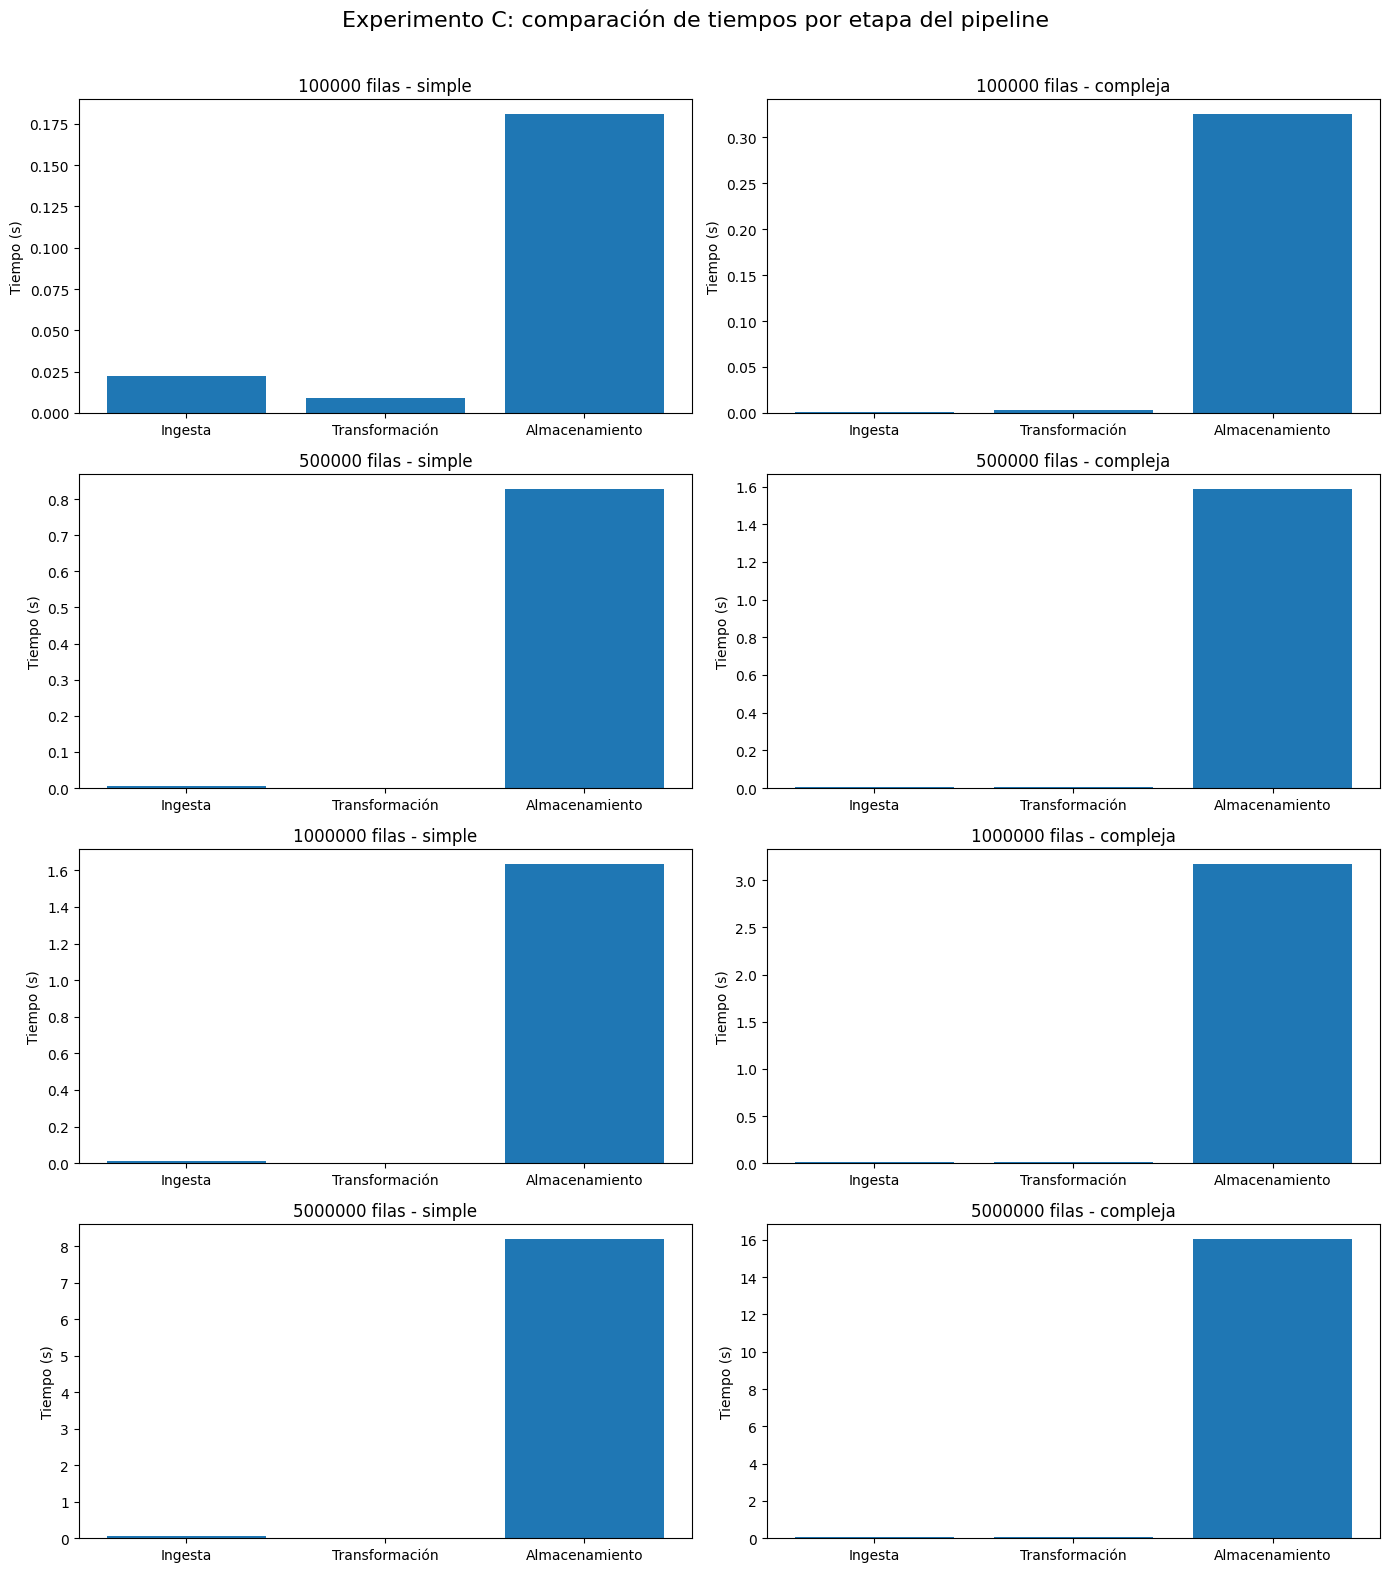

In [29]:
# Carpeta de visualizaciones
vis_dir = Path("../visualizaciones")
vis_dir.mkdir(exist_ok=True)
# Crear figura con 4 filas y 2 columnas
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
# Recorrer cada configuración
for i, (_, row) in enumerate(df_resultados_c.iterrows()):
    axes[i].bar(
        ["Ingesta", "Transformación", "Almacenamiento"],
        [row["ingesta_s"], row["transformacion_s"], row["almacenamiento_s"]]
    )
    axes[i].set_title(f"{row['n_rows']} filas - {row['transformacion']}")
    axes[i].set_ylabel("Tiempo (s)")
# Título general
fig.suptitle("Experimento C: comparación de tiempos por etapa del pipeline", fontsize=16)
# Ajustar espacios
plt.tight_layout(rect=[0, 0, 1, 0.97])
# Guardar imagen completa
plt.savefig(vis_dir / "grafico_experimento_c_completo.png", dpi=300)

# Mostrar
plt.show()